Problem 1: Divide and Conquer – Merge Sort

Original List: [55, 12, 78, 4, 99, 31, 18]
Sorted List: [4, 12, 18, 31, 55, 78, 99]
Input: 200 Time: 0.00026106834411621094
Input: 400 Time: 0.0005056858062744141
Input: 800 Time: 0.0010187625885009766
Input: 1600 Time: 0.002062082290649414
Input: 3200 Time: 0.004585981369018555


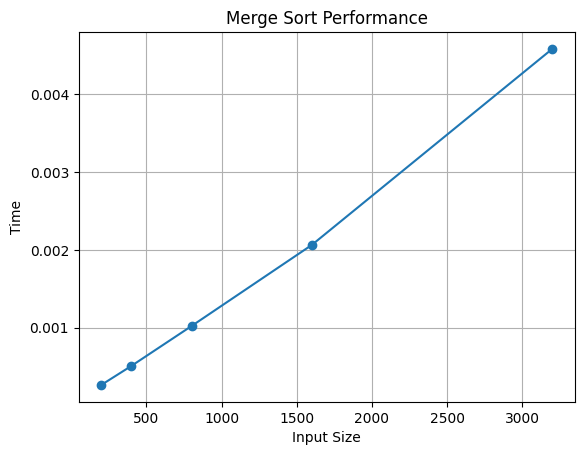

In [2]:
import random
import time
import matplotlib.pyplot as plt

def merge(left_part, right_part):
    sorted_list = []
    left_index = 0
    right_index = 0

    while left_index < len(left_part) and right_index < len(right_part):
        if left_part[left_index] <= right_part[right_index]:
            sorted_list.append(left_part[left_index])
            left_index += 1
        else:
            sorted_list.append(right_part[right_index])
            right_index += 1

    while left_index < len(left_part):
        sorted_list.append(left_part[left_index])
        left_index += 1

    while right_index < len(right_part):
        sorted_list.append(right_part[right_index])
        right_index += 1

    return sorted_list

def merge_sort(numbers):
    if len(numbers) <= 1:
        return numbers

    middle = len(numbers) // 2

    first_half = merge_sort(numbers[:middle])
    second_half = merge_sort(numbers[middle:])

    return merge(first_half, second_half)

sizes = [200, 400, 800, 1600, 3200]
time_taken = []

for n in sizes:
    values = [random.randint(10, 5000) for i in range(n)]

    start = time.time()
    merge_sort(values)
    end = time.time()

    time_taken.append(end - start)

example = [55, 12, 78, 4, 99, 31, 18]

print("Original List:", example)
print("Sorted List:", merge_sort(example))

for i in range(len(sizes)):
    print("Input:", sizes[i], "Time:", time_taken[i])

plt.plot(sizes, time_taken, marker='o')
plt.title("Merge Sort Performance")
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.grid(True)
plt.show()

Problem 2: Sorting Performance Comparison (Merge Sort & Bubble Sort)

Merge Sort Times: [0.0004150867462158203, 0.0010366439819335938, 0.0015130043029785156, 0.0021851062774658203, 0.003564119338989258]
Bubble Sort Times: [0.0013949871063232422, 0.0048792362213134766, 0.01633596420288086, 0.05005526542663574, 0.19607305526733398]


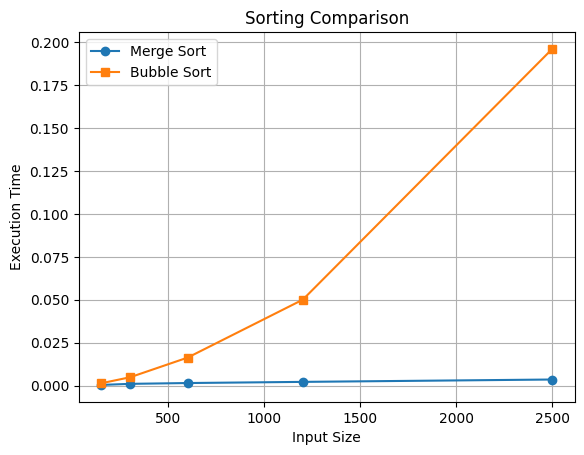

In [3]:
import random
import time
import matplotlib.pyplot as plt

def bubble_sort(arr):
    length = len(arr)

    for i in range(length):
        for j in range(length - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]

    return arr

def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    center = len(arr) // 2
    left_side = merge_sort(arr[:center])
    right_side = merge_sort(arr[center:])

    return combine(left_side, right_side)

def combine(a, b):
    final = []

    while len(a) > 0 and len(b) > 0:
        if a[0] < b[0]:
            final.append(a.pop(0))
        else:
            final.append(b.pop(0))

    final.extend(a)
    final.extend(b)

    return final

sizes = [150, 300, 600, 1200, 2500]
merge_result = []
bubble_result = []

for size in sizes:
    dataset = [random.randint(50, 10000) for i in range(size)]

    data1 = dataset.copy()
    data2 = dataset.copy()

    start = time.time()
    merge_sort(data1)
    end = time.time()
    merge_result.append(end - start)

    start = time.time()
    bubble_sort(data2)
    end = time.time()
    bubble_result.append(end - start)

print("Merge Sort Times:", merge_result)
print("Bubble Sort Times:", bubble_result)

plt.plot(sizes, merge_result, marker='o', label='Merge Sort')
plt.plot(sizes, bubble_result, marker='s', label='Bubble Sort')
plt.title("Sorting Comparison")
plt.xlabel("Input Size")
plt.ylabel("Execution Time")
plt.legend()
plt.grid(True)
plt.show()

Problem 3: Greedy Algorithm (Fractional Knapsack)

Weights: [8, 16, 24, 40]
Profits: [40, 100, 120, 280]
Capacity: 50
Maximum Profit: 342.5
Fractions Selected: [1, 0.625]


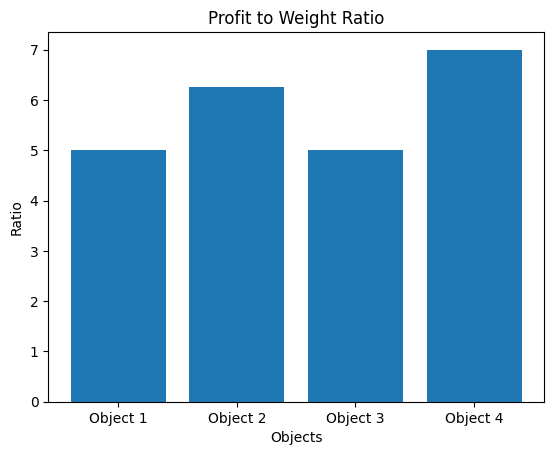

In [4]:
import matplotlib.pyplot as plt

def fractional_knapsack(weights, profits, bag_capacity):
    object_list = []

    for i in range(len(weights)):
        ratio = profits[i] / weights[i]
        object_list.append([weights[i], profits[i], ratio])

    object_list.sort(key=lambda x: x[2], reverse=True)

    final_profit = 0
    selected_fraction = []

    for item in object_list:
        weight = item[0]
        profit = item[1]

        if bag_capacity >= weight:
            bag_capacity -= weight
            final_profit += profit
            selected_fraction.append(1)
        else:
            taken = bag_capacity / weight
            final_profit += profit * taken
            selected_fraction.append(taken)
            break

    return final_profit, selected_fraction

weights = [8, 16, 24, 40]
profits = [40, 100, 120, 280]
capacity = 50

best_profit, selected = fractional_knapsack(weights, profits, capacity)

print("Weights:", weights)
print("Profits:", profits)
print("Capacity:", capacity)
print("Maximum Profit:", best_profit)
print("Fractions Selected:", selected)

labels = ["Object 1", "Object 2", "Object 3", "Object 4"]
ratios = [profits[i] / weights[i] for i in range(len(weights))]

plt.bar(labels, ratios)
plt.title("Profit to Weight Ratio")
plt.xlabel("Objects")
plt.ylabel("Ratio")
plt.show()


Problem 4: Dynammic Programming (0/1 Knapsack)

In [5]:
def knapsack_01(weights, profits, max_capacity):
    total_items = len(weights)

    table = [[0 for x in range(max_capacity + 1)] for y in range(total_items + 1)]

    for i in range(1, total_items + 1):
        for j in range(1, max_capacity + 1):
            if weights[i - 1] <= j:
                include_item = profits[i - 1] + table[i - 1][j - weights[i - 1]]
                exclude_item = table[i - 1][j]
                table[i][j] = max(include_item, exclude_item)
            else:
                table[i][j] = table[i - 1][j]

    return table[total_items][max_capacity]

weights = [14, 22, 18, 35, 40]
profits = [80, 120, 100, 210, 240]
capacity = 60

answer = knapsack_01(weights, profits, capacity)

print("Weights:", weights)
print("Profits:", profits)
print("Capacity:", capacity)
print("Best Profit:", answer)

Weights: [14, 22, 18, 35, 40]
Profits: [80, 120, 100, 210, 240]
Capacity: 60
Best Profit: 340
